## 14. RBA Forecast Error Benchmark Preparation

This section uses the newly retrieved RBA historical CPI forecast file as a benchmark-preparation diagnostic. It summarises forecast errors by published horizon only; formal model comparison still belongs in the rolling-origin modelling stage, where SARIMA/SARIMAX/Elastic Net forecasts can be aligned to the same horizons.


,horizon_quarters,n_forecasts,start_forecast_date,end_forecast_date,mean_error,mae,rmse
0,0,121,1995-03-01,2025-02-01,-0.018,0.207,0.287
1,1,121,1995-03-01,2025-02-01,-0.022,0.436,0.601
2,2,121,1995-03-01,2025-02-01,-0.025,0.633,0.894
3,3,121,1995-03-01,2025-02-01,-0.059,0.845,1.197
4,4,120,1995-03-01,2024-11-01,-0.065,1.012,1.419
5,5,119,1995-03-01,2024-08-01,-0.050,1.110,1.555
6,6,113,1995-06-01,2024-05-01,0.013,1.139,1.619
7,7,94,1995-06-01,2024-02-01,0.041,1.203,1.727
8,8,75,1995-06-01,2023-11-01,0.163,1.253,1.823
9,9,43,1998-03-01,2023-08-01,0.216,1.184,1.686


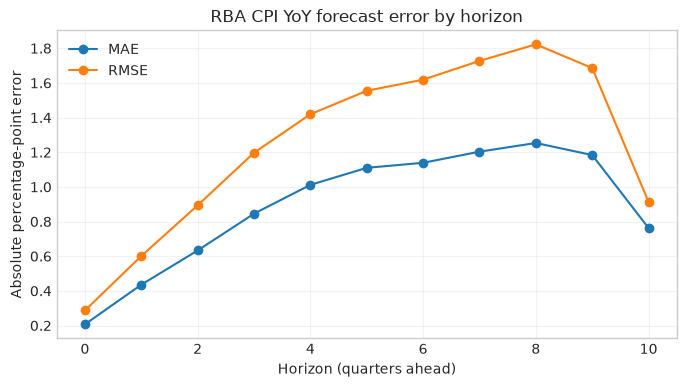

RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.

In [16]:
RBA_FORECAST_PATH = ROOT / 'dataset' / 'rba' / 'rba_historical_cpi_forecasts_by_horizon_1995_2025.csv'

if RBA_FORECAST_PATH.exists():
    rba_forecasts = pd.read_csv(RBA_FORECAST_PATH)
    rba_forecasts['forecast_date'] = pd.to_datetime(rba_forecasts['forecast_date'], errors='coerce')
    rba_eval = rba_forecasts.loc[
        rba_forecasts['horizon_quarters'].ge(0)
        & rba_forecasts['rba_forecast_cpi_yoy'].notna()
        & rba_forecasts['rba_actual_cpi_yoy'].notna()
    ].copy()
    if 'rba_forecast_error_cpi_yoy' not in rba_eval or rba_eval['rba_forecast_error_cpi_yoy'].isna().all():
        rba_eval['rba_forecast_error_cpi_yoy'] = rba_eval['rba_actual_cpi_yoy'] - rba_eval['rba_forecast_cpi_yoy']
    rba_eval = rba_eval.loc[rba_eval['rba_forecast_error_cpi_yoy'].notna()].copy()

    rba_horizon_error = (
        rba_eval.groupby('horizon_quarters')
        .agg(
            n_forecasts=('rba_forecast_error_cpi_yoy', 'size'),
            start_forecast_date=('forecast_date', 'min'),
            end_forecast_date=('forecast_date', 'max'),
            mean_error=('rba_forecast_error_cpi_yoy', 'mean'),
            mae=('rba_forecast_error_cpi_yoy', lambda s: s.abs().mean()),
            rmse=('rba_forecast_error_cpi_yoy', lambda s: np.sqrt(np.mean(np.square(s)))),
        )
        .reset_index()
    )
    rba_horizon_error['start_forecast_date'] = rba_horizon_error['start_forecast_date'].dt.strftime('%Y-%m-%d')
    rba_horizon_error['end_forecast_date'] = rba_horizon_error['end_forecast_date'].dt.strftime('%Y-%m-%d')
    display(rba_horizon_error.round({'mean_error': 3, 'mae': 3, 'rmse': 3}))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['mae'], marker='o', label='MAE')
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['rmse'], marker='o', label='RMSE')
    ax.set_title('RBA CPI YoY forecast error by horizon')
    ax.set_xlabel('Horizon (quarters ahead)')
    ax.set_ylabel('Absolute percentage-point error')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

    display(Markdown('RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.'))
else:
    rba_horizon_error = pd.DataFrame()
    display(Markdown('RBA historical CPI forecast data is not present, so RBA forecast-error benchmarking remains blocked until the source file is retrieved.'))
